# Filter

basially a dup of flare filtering

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


## Download

In [2]:
download_chandra_obsid 1843 evt2
mv 1843/primary/acisf01843N003_evt2.fits.gz .
gunzip -f acisf01843N003_evt2.fits.gz
rmdir -p 1843/primary


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  evt2     fits       17 Mb  ####################          < 1 s  69470.4 kb/s



## Restrict Energy Rnage

In [3]:
dmcopy "acisf01843N003_evt2.fits[energy=300:10000]" acis_1843_evt2_0.3-10.fits  clob+

## Using exclude filter

In [4]:
dmcopy "acisf01843N003_evt2.fits[exclude ccd_id=0:4,6,8:9]" acis_1843_evt2_bi.fits clob+

In [5]:
dmcopy "acisf01843N003_evt2.fits[exclude ccd_id=0:4,6,8:9]" acis_1843_evt2_bi.fits  clob+

## Apply Time Filters


In [6]:
dmcopy "acisf01843N003_evt2.fits[time=60413209:60414209]" acis_1843_evt2_1000s.fits clob+

## High Background Times

In [7]:
cat << EOM > obj.reg 
# Region file format: CIAO version 1.0
ellipse(1628,4116,100,140,0)
EOM


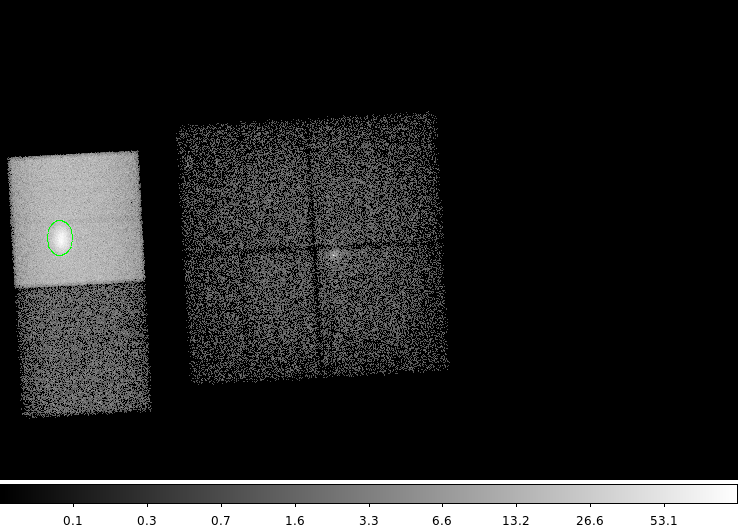

In [8]:
ds9 acis_1843_evt2_0.3-10.fits -region obj.reg -bin factor 8 -scale log  \
  -saveimage png ds9_01.png -quit

display < ds9_01.png

### 3. Extract background light curve

In [9]:
pset dmextract \
    infile="acis_1843_evt2_0.3-10.fits[sky=field()-ellipse(1628,4116,100,140,0)][bin time=::3.24104]"
pset dmextract outfile=background_lc.fits
pset dmextract opt=ltc1
dmextract mode=h clob+

## 4. Examine lc

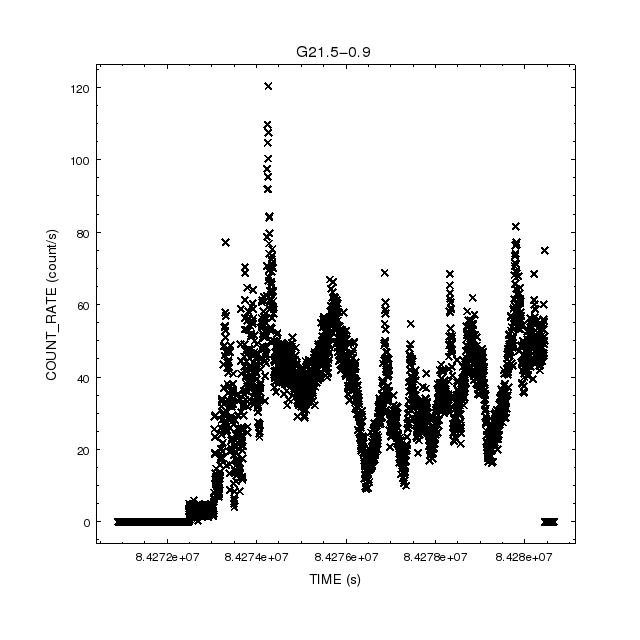

In [10]:
cat << EOM > c1.py
make_figure("background_lc.fits[cols time,count_rate]", "line.style=none")
print_window("chips_01.png", "export.clobber=True")
quit()
EOM

chips -n c1.py
display < chips_01.png

In [11]:
dmstat "background_lc.fits[cols count_rate]" 

COUNT_RATE[count/s]
    min:	0 	      @:	1 
    max:	120.31249977 	      @:	1037 
   mean:	28.92197788 
  sigma:	19.960021086 
    sum:	86968.387484 
   good:	3007 
   null:	0 



In [12]:
dmlist "background_lc.fits[cols time,count_rate][#row=1030:1045]" data

 
--------------------------------------------------------------------------------
Data for Table Block LIGHTCURVE
--------------------------------------------------------------------------------
 
ROW    TIME                 COUNT_RATE
 
     1  84274238.8191800117        91.8749998220
     2  84274242.0602200031        91.8749998220
     3  84274245.3012599945       109.6874997875
     4  84274248.5423000157       104.6874997972
     5  84274251.7833400071        91.8749998220
     6  84274255.0243799984        95.3124998153
     7  84274258.2654200196       100.3124998056
     8  84274261.5064600110       120.3124997669
     9  84274264.7475000024       107.4999997917
    10  84274267.9885400236        66.5624998710
    11  84274271.2295800149        69.3749998656
    12  84274274.4706200063        67.4999998692
    13  84274277.7116599977        76.8749998510
    14  84274280.9527000189        74.0624998565
    15  84274284.1937400103        84.0624998371
    16  84274287.434780001

In [13]:
dmlist "background_lc.fits[cols time,count_rate][count_rate>65]" data | head -20

 
--------------------------------------------------------------------------------
Data for Table Block LIGHTCURVE
--------------------------------------------------------------------------------
 
ROW    TIME                 COUNT_RATE
 
     1  84273308.6407000124        77.1874998504
     2  84273742.9400600195        70.3124998638
     3  84273746.1811000109        68.7499998668
     4  84274229.0960600078        70.6249998632
     5  84274232.3370999992        78.7499998474
     6  84274235.5781400204        97.4999998111
     7  84274238.8191800117        91.8749998220
     8  84274242.0602200031        91.8749998220
     9  84274245.3012599945       109.6874997875
    10  84274248.5423000157       104.6874997972
    11  84274251.7833400071        91.8749998220
    12  84274255.0243799984        95.3124998153
    13  84274258.2654200196       100.3124998056


### Create GTI

In [14]:
pset dmgti infile=background_lc.fits
pset dmgti outfile=bkg_gti.fits
pset dmgti userlimit="count_rate<=80.0"
dmgti clobber=yes mode=h

In [15]:
dmlist bkg_gti.fits blocks,subspace

 
--------------------------------------------------------------------------------
Dataset: bkg_gti.fits
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: FILTER                         Table         1 cols x 0        rows
Block    3: GTI                            Table         2 cols x 5        rows
 
--------------------------------------------------------------------------------
Data subspace for block FILTER: Components: 1 Descriptors: 1 
--------------------------------------------------------------------------------
 
 --- Component 1 --- 
   1 TIME                 Real8               TABLE GTI
                                              
                                               84270902.1685000062: 84274233.9576200247
         

### 6. Apply


In [16]:
dmcopy "acis_1843_evt2_0.3-10.fits[@bkg_gti.fits]" acis_1843_evt2_0.3-10_bkgflt.fits  clob+



### 7. Check

In [17]:
dmlist acis_1843_evt2_0.3-10.fits header | grep EXPO

0119 EXPOSURE                  7854.4664748540 [s]       Real8        Exposure time
0120 EXPOSUR7                  7854.4664748540 [s]       Real8        Exposure time
0121 EXPOSUR6                  7854.4664748540 [s]       Real8        Exposure time
0122 EXPOSUR3                  7851.2665536036 [s]       Real8        Exposure time
0123 EXPOSUR2                  7854.4664748540 [s]       Real8        Exposure time
0124 EXPOSUR1                  7854.4664748540 [s]       Real8        Exposure time
0125 EXPOSUR0                  7854.4664748540 [s]       Real8        Exposure time


In [18]:
dmlist acis_1843_evt2_0.3-10_bkgflt.fits header | grep EXPO

0119 EXPOSURE                  7812.8664748764 [s]       Real8        Exposure time
0120 EXPOSUR7                  7812.8664748764 [s]       Real8        Exposure time
0121 EXPOSUR6                  7812.8664748764 [s]       Real8        Exposure time
0122 EXPOSUR3                  7809.6665536260 [s]       Real8        Exposure time
0123 EXPOSUR2                  7812.8664748764 [s]       Real8        Exposure time
0124 EXPOSUR1                  7812.8664748764 [s]       Real8        Exposure time
0125 EXPOSUR0                  7812.8664748764 [s]       Real8        Exposure time
